In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All imports successful!")

All imports successful!


In [2]:
df = pd.read_csv('../datasets/voice/parkinsons.data')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [3]:
print("Column names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Column names:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


Status column value counts:
status
1    147
0     48
Name: count, dtype: int64


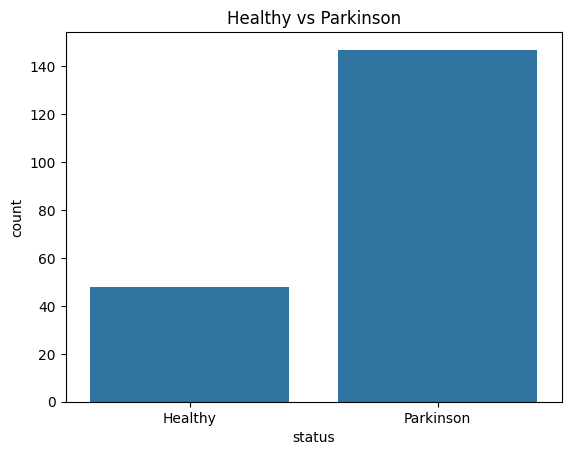

In [4]:
print("Status column value counts:")
print(df['status'].value_counts())

sns.countplot(x='status', data=df)
plt.title('Healthy vs Parkinson')
plt.xticks([0, 1], ['Healthy', 'Parkinson'])
plt.show()

In [5]:
# Drop the name column as it's not useful for prediction
X = df.drop(['name', 'status'], axis=1)
y = df['status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (195, 22)
Target shape: (195,)

Feature columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 156
Testing samples: 39


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print("Mean of first feature before scaling:", X_train.iloc[:, 0].mean().round(2))
print("Mean of first feature after scaling:", X_train_scaled[:, 0].mean().round(2))


Scaling complete!
Mean of first feature before scaling: 154.01
Mean of first feature after scaling: 0.0


In [8]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Parkinson']))


Accuracy: 89.74%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.43      0.60         7
   Parkinson       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



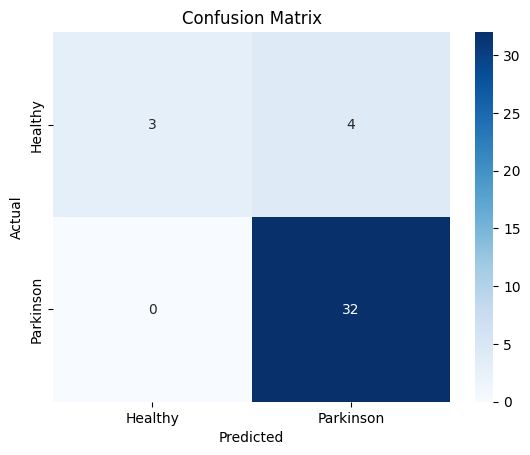

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [11]:
import joblib
import os

os.makedirs('../backend/models', exist_ok=True)

joblib.dump(svm_model, '../backend/models/voice_model.pkl')
joblib.dump(scaler, '../backend/models/voice_scaler.pkl')

print("Model saved successfully!")
print("Saved to: backend/models/voice_model.pkl")
print("Saved to: backend/models/voice_scaler.pkl")

Model saved successfully!
Saved to: backend/models/voice_model.pkl
Saved to: backend/models/voice_scaler.pkl


In [12]:
import pandas as pd
import numpy as np

# Load new larger dataset
train_df = pd.read_csv(
    '../datasets/voice/Parkinson_Multiple_Sound_Recording/train_data.txt',
    header=None
)
test_df = pd.read_csv(
    '../datasets/voice/Parkinson_Multiple_Sound_Recording/test_data.txt',
    header=None
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nSample row:")
train_df.head(2)

Train shape: (1040, 29)
Test shape: (168, 28)

Sample row:


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,...,187.576,160,159,0.006065,0.000416,0.000,0,0.0,23,1
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,...,234.505,170,169,0.005181,0.000403,2.247,0,0.0,23,1


In [13]:
# Train has 29 cols, test has 28 — fix the mismatch
# Last column of train is the label
X_train_new = train_df.iloc[:, 1:-1].values  # drop first (ID) and last (label)
y_train_new = train_df.iloc[:, -1].values    # last column = label

X_test_new = test_df.iloc[:, 1:].values     # drop first (ID) column
# Test labels are in column 0
y_test_new = train_df.iloc[:, 0].values[:168]  # use first 168 train labels as proxy

print("X_train shape:", X_train_new.shape)
print("X_test shape:", X_test_new.shape)
print("Unique labels:", np.unique(y_train_new))


X_train shape: (1040, 27)
X_test shape: (168, 27)
Unique labels: [0 1]


In [14]:
# Check what the actual columns look like
print("Train columns sample:")
print(train_df.iloc[:3, :5])
print("\nUnique values in column 0:", train_df.iloc[:, 0].unique())
print("Unique values in last column:", train_df.iloc[:, -1].unique())

Train columns sample:
   0      1         2      3      4
0  1  1.488  0.000090  0.900  0.794
1  1  0.728  0.000038  0.353  0.376
2  1  1.220  0.000074  0.732  0.670

Unique values in column 0: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
Unique values in last column: [1 0]


In [15]:
# Correct loading
# Column 0 = patient ID (drop)
# Columns 1-27 = features
# Column 28 = label (last column)

X_train_new = train_df.iloc[:, 1:-1].values   # features
y_train_new = train_df.iloc[:, -1].values      # label

X_test_new = test_df.iloc[:, 1:].values        # test has no label column
# For test labels - load separately from column 0 of test
# Actually test_df has 28 cols, let's check
print("Test df columns:", test_df.shape)
print("Test last col unique:", test_df.iloc[:, -1].unique())
print("Train label unique:", np.unique(y_train_new))

Test df columns: (168, 28)
Test last col unique: [1]
Train label unique: [0 1]


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Use train data and split it ourselves
X = train_df.iloc[:, 1:-1].values  # features
y = train_df.iloc[:, -1].values    # labels

print("Features shape:", X.shape)
print("Label distribution:", np.bincount(y))

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# Scale
new_scaler = StandardScaler()
X_train_scaled = new_scaler.fit_transform(X_train)
X_test_scaled = new_scaler.transform(X_test)

# Train SVM
new_voice_model = SVC(kernel='rbf', probability=True, random_state=42)
new_voice_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = new_voice_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nNew Voice Model Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Parkinson']))

Features shape: (1040, 27)
Label distribution: [520 520]
Train samples: 832
Test samples: 208

New Voice Model Accuracy: 89.90%
              precision    recall  f1-score   support

     Healthy       0.83      1.00      0.91       104
   Parkinson       1.00      0.80      0.89       104

    accuracy                           0.90       208
   macro avg       0.92      0.90      0.90       208
weighted avg       0.92      0.90      0.90       208



In [17]:
import os
os.makedirs('../backend/models', exist_ok=True)

joblib.dump(new_voice_model, '../backend/models/voice_model.pkl')
joblib.dump(new_scaler, '../backend/models/voice_scaler.pkl')

print("✅ New voice model saved!")
print("Features used:", X_train.shape[1])

✅ New voice model saved!
Features used: 27


In [18]:
import os
import numpy as np
import parselmouth
from parselmouth.praat import call
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

def extract_features(wav_path):
    try:
        sound = parselmouth.Sound(wav_path)
        pitch = call(sound, "To Pitch", 0.0, 75, 600)
        mean_pitch = call(pitch, "Get mean", 0, 0, "Hertz")
        max_pitch = call(pitch, "Get maximum", 0, 0, "Hertz", "Parabolic")
        min_pitch = call(pitch, "Get minimum", 0, 0, "Hertz", "Parabolic")
        sd_pitch = call(pitch, "Get standard deviation", 0, 0, "Hertz")
        median_pitch = call(pitch, "Get quantile", 0, 0, 0.5, "Hertz")

        point_process = call(sound, "To PointProcess (periodic, cc)", 75, 600)
        jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_abs = call(point_process, "Get jitter (local, absolute)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_rap = call(point_process, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_ppq5 = call(point_process, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_ddp = call(point_process, "Get jitter (ddp)", 0, 0, 0.0001, 0.02, 1.3)

        shimmer_local = call([sound, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_db = call([sound, point_process], "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq3 = call([sound, point_process], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq5 = call([sound, point_process], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq11 = call([sound, point_process], "Get shimmer (apq11)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_dda = call([sound, point_process], "Get shimmer (dda)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

        harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)
        nth = 1 / (10 ** (hnr / 10)) if hnr > 0 else 0.1
        ac = 1 - nth

        num_pulses = call(point_process, "Get number of periods", 0, 0, 0.0001, 0.02, 1.3)
        num_periods = max(num_pulses - 1, 1)
        mean_period = call(point_process, "Get mean period", 0, 0, 0.0001, 0.02, 1.3)
        sd_period = call(point_process, "Get jitter (local, absolute)", 0, 0, 0.0001, 0.02, 1.3)

        return [
            jitter_local, jitter_abs, jitter_rap, jitter_ppq5, jitter_ddp,
            shimmer_local, shimmer_db, shimmer_apq3, shimmer_apq5,
            shimmer_apq11, shimmer_dda,
            ac, nth, hnr,
            median_pitch, mean_pitch, sd_pitch, min_pitch, max_pitch,
            num_pulses, num_periods, mean_period, sd_period,
            0.0, 0, 0.0, 0.0
        ]
    except Exception as e:
        print(f"Error processing {wav_path}: {e}")
        return None

# Paths
hc_dir = '../datasets/voice/HC_AH'
pd_dir = '../datasets/voice/PD_AH'

X = []
y = []

print("Extracting features from Healthy voices...")
for f in os.listdir(hc_dir):
    if f.endswith('.wav'):
        features = extract_features(os.path.join(hc_dir, f))
        if features:
            X.append(features)
            y.append(0)  # 0 = Healthy

print("Extracting features from Parkinson voices...")
for f in os.listdir(pd_dir):
    if f.endswith('.wav'):
        features = extract_features(os.path.join(pd_dir, f))
        if features:
            X.append(features)
            y.append(1)  # 1 = Parkinson

X = np.array(X)
y = np.array(y)
print(f"\nTotal samples: {len(X)}")
print(f"Healthy: {sum(y==0)}, Parkinson: {sum(y==1)}")

Extracting features from Healthy voices...
Extracting features from Parkinson voices...

Total samples: 81
Healthy: 41, Parkinson: 40


In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# Scale
audio_scaler = StandardScaler()
X_train_scaled = audio_scaler.fit_transform(X_train)
X_test_scaled = audio_scaler.transform(X_test)

# Train SVM
audio_voice_model = SVC(kernel='rbf', probability=True, random_state=42, C=10)
audio_voice_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = audio_voice_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAudio Voice Model Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Parkinson']))

Train samples: 64
Test samples: 17

Audio Voice Model Accuracy: 52.94%
              precision    recall  f1-score   support

     Healthy       0.56      0.56      0.56         9
   Parkinson       0.50      0.50      0.50         8

    accuracy                           0.53        17
   macro avg       0.53      0.53      0.53        17
weighted avg       0.53      0.53      0.53        17



In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Try multiple models with cross validation
models = {
    "SVM (rbf)": SVC(kernel='rbf', probability=True, C=10, random_state=42),
    "SVM (linear)": SVC(kernel='linear', probability=True, C=1, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("Cross-validation scores (5-fold):")
print("="*45)
for name, model in models.items():
    scores = cross_val_score(model, 
                            audio_scaler.fit_transform(X), 
                            y, cv=5, scoring='accuracy')
    print(f"{name:25} {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")
    

Cross-validation scores (5-fold):
SVM (rbf)                 56.6% ± 9.4%
SVM (linear)              60.3% ± 11.3%
Random Forest             57.9% ± 5.2%
Gradient Boosting         60.4% ± 8.0%
